In [ ]:
!wget --no-check-certificate https://madm.dfki.de/files/sentinel/EuroSAT.zip
!unzip -q EuroSAT.zip

--2026-04-03 04:53:31--  https://madm.dfki.de/files/sentinel/EuroSAT.zip
Resolving madm.dfki.de (madm.dfki.de)... 131.246.195.183
Connecting to madm.dfki.de (madm.dfki.de)|131.246.195.183|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 94280567 (90M) [application/zip]
Saving to: ‘EuroSAT.zip.3’

EuroSAT.zip.3       100%[===================>]  89.91M  21.1MB/s    in 5.3s    

2026-04-03 04:53:37 (16.9 MB/s) - ‘EuroSAT.zip.3’ saved [94280567/94280567]

replace 2750/River/River_479.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    '2750',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    '2750',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=8,
    validation_data=val_generator
)

Epoch 1/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 482s 714ms/step - accuracy: 0.8779 - loss: 0.3581 - val_accuracy: 0.8976 - val_loss: 0.3023
Epoch 2/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 478s 708ms/step - accuracy: 0.8790 - loss: 0.3593 - val_accuracy: 0.8978 - val_loss: 0.2930
Epoch 3/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 475s 704ms/step - accuracy: 0.8778 - loss: 0.3583 - val_accuracy: 0.8985 - val_loss: 0.3002
Epoch 4/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 465s 689ms/step - accuracy: 0.8847 - loss: 0.3447 - val_accuracy: 0.9015 - val_loss: 0.2878
Epoch 5/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 476s 705ms/step - accuracy: 0.8822 - loss: 0.3435 - val_accuracy: 0.9015 - val_loss: 0.2825
Epoch 6/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 469s 693ms/step - accuracy: 0.8827 - loss: 0.3394 - val_accuracy: 0.9009 - val_loss: 0.2812
Epoch 7/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 483s 715ms/step - accuracy: 0.8871 - loss: 0.3398 - val_accuracy: 0.9050 - val_loss: 0.2771
Epoch 8/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 487s 721ms/step - accuracy: 0.8869 - loss: 0

In [ ]:
val_generator.reset()
preds = model.predict(val_generator)
pred_classes = np.argmax(preds, axis=1)

true_classes = val_generator.classes

class_labels = list(train_generator.class_indices.keys())

mining_classes = ['Industrial', 'AnnualCrop']

def convert_to_binary(labels):
    binary = []
    for l in labels:
        class_name = class_labels[l]
        if class_name in mining_classes:
            binary.append(1)
        else:
            binary.append(0)
    return np.array(binary)

y_true_binary = convert_to_binary(true_classes)
y_pred_binary = convert_to_binary(pred_classes)

169/169 ━━━━━━━━━━━━━━━━━━━━ 105s 604ms/step


In [ ]:
print("Classification Report:\n")
print(classification_report(y_true_binary, y_pred_binary))

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.80      0.80      4300
           1       0.20      0.19      0.19      1100

    accuracy                           0.68      5400
   macro avg       0.50      0.50      0.50      5400
weighted avg       0.67      0.68      0.67      5400



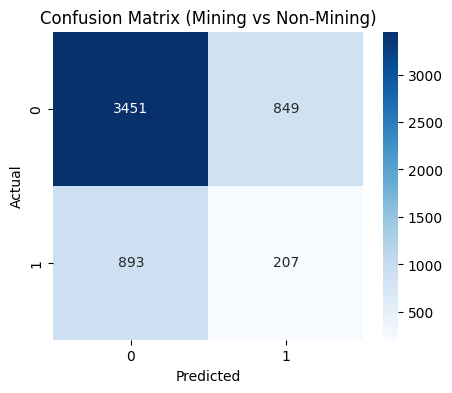

In [ ]:
cm = confusion_matrix(y_true_binary, y_pred_binary)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Mining vs Non-Mining)")

plt.show()

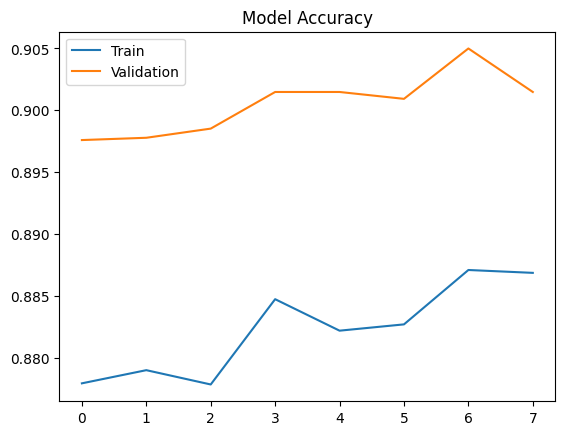

In [ ]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.legend()
plt.title("Model Accuracy")

plt.show()

In [ ]:
model.save("mining_model.h5")

In [ ]:
from google.colab import files
files.download("mining_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>